In [1]:
import sympy as sp
import numpy as np
import dg_geometry as DG503

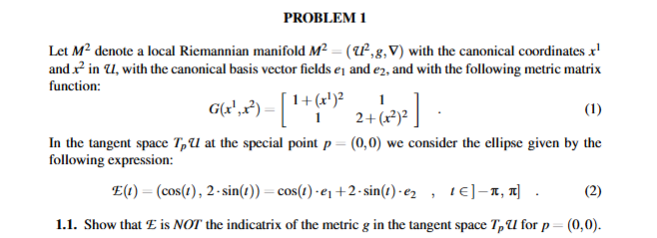

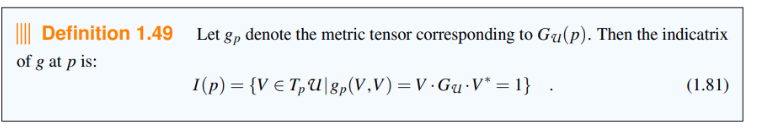

In [ ]:
x1, x2, t = sp.symbols('x1 x2 t', real=True)

G = sp.Matrix([[1 + x1**2, 1], [1, 2 + x2**2]])

E = sp.Matrix([sp.cos(t),2*sp.sin(t)])

display(G)
display(E)

G_k = G.subs({x1: 0, x2: 0})

I = DG503.calculate_g_dot(G_k, E, E)
display(sp.simplify(I))

Matrix([
[x1**2 + 1,         1],
[        1, x2**2 + 2]])

Matrix([
[  cos(t)],
[2*sin(t)]])

2*sin(2*t) - 7*cos(2*t)/2 + 9/2

This is different from 0

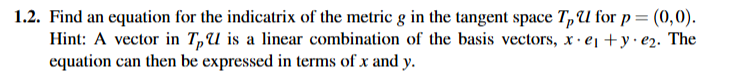

In [29]:
x, y = sp.symbols('x y', real=True)

E_2 = sp.Matrix([x, y])

I = DG503.calculate_g_dot(G_k, E_2, E_2)

display(sp.simplify(I))
display(sp.expand(I))

x*(x + y) + y*(x + 2*y)

x**2 + 2*x*y + 2*y**2

Find an equation pls remember this

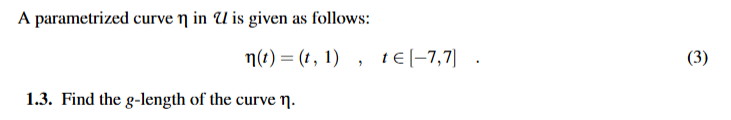

In [48]:
# 1. Define the curve
eta = sp.Matrix([t, 1])

# 2. Find the velocity vector (the derivative)
# This is the 'v' that goes into the metric norm
eta_prime = eta.diff(t) 

# 3. Use the metric at the point eta(t)
G_eta = G.subs({x1: t, x2: 1})

# 4. Calculate the norm of the VELOCITY
integrand = DG503.calculate_g_norm(G_eta, eta_prime)

# 5. Integrate
L_eta = sp.integrate(integrand, (t, -7, 7))
display(L_eta)
display(sp.N(L_eta))

asinh(7) + 35*sqrt(2)

52.1415954441170

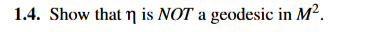

In [42]:
coords = sp.Matrix([x1,x2])
G = sp.Matrix([[1 + x1**2, 1], [1, 2 + x2**2]])

acc = DG503.calculate_curve_acceleration(G, eta, t, coords)

display(sp.simplify(acc))

Matrix([
[3*t/(3*t**2 + 2)],
[ -t/(3*t**2 + 2)]])

It does not simplify to 0

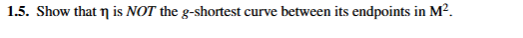

Beacause it is not a geodesic it is not shorter. Bu we can try other curves

In [ ]:
# 1. Define the curve
eta = sp.Matrix([t, 1 ]) + acc
display(eta)

# 2. Find the velocity vector (the derivative)
# This is the 'v' that goes into the metric norm
eta_prime = eta.diff(t) 

# 3. Use the metric at the point eta(t)
G_eta = G.subs({x1: t, x2: 1})

# 4. Calculate the norm of the VELOCITY
integrand = DG503.calculate_g_norm(G_eta, eta_prime)

# 5. Integrate
L_eta = sp.integrate(integrand, (t, -7, 7))
display(sp.N(L_eta))

Matrix([
[t + 3*t/(3*t**2 + 2)],
[ -t/(3*t**2 + 2) + 1]])

Matrix([
[(6561*t**15 - 1458*t**14 + 37422*t**13 - 7290*t**12 + 90720*t**11 - 16281*t**10 + 53325*t**9 - 1512*t**8 - 90837*t**7 + 23652*t**6 - 110820*t**5 + 12456*t**4 - 26140*t**3 - 320*t**2 + 2560*t - 32)/(6561*t**16 - 1458*t**15 + 48357*t**14 - 10206*t**13 + 142236*t**12 - 26730*t**11 + 221643*t**10 - 35208*t**9 + 201222*t**8 - 25488*t**7 + 108564*t**6 - 10080*t**5 + 33416*t**4 - 1952*t**3 + 5120*t**2 - 128*t + 256)],
[                 (-2187*t**15 - 12393*t**13 + 1215*t**12 - 30132*t**11 + 3807*t**10 - 17712*t**9 - 2727*t**8 + 30753*t**7 - 11466*t**6 + 37368*t**5 - 6108*t**4 + 8780*t**3 - 328*t**2 - 864*t + 32)/(6561*t**16 - 1458*t**15 + 48357*t**14 - 10206*t**13 + 142236*t**12 - 26730*t**11 + 221643*t**10 - 35208*t**9 + 201222*t**8 - 25488*t**7 + 108564*t**6 - 10080*t**5 + 33416*t**4 - 1952*t**3 + 5120*t**2 - 128*t + 256)]])

50.3967275671130

If we move it along the acceleration we come closer

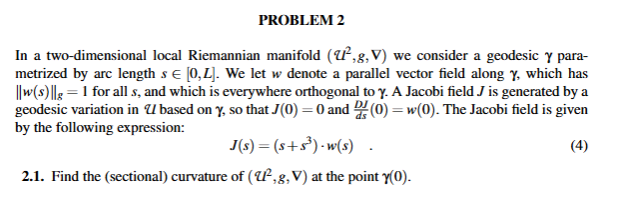

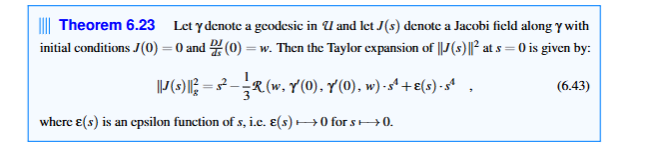

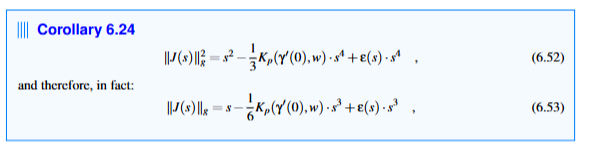

In [64]:
s, K_p, epsilon = sp.symbols('s K_p epsilon', real=True)

w = sp.Function('w')(s)

J = (s+s**3)*w

display(J)

eq = sp.Eq(s**2 -sp.Rational(1,3)*K_p*s**4 + epsilon*s**4, J**2)
display(eq)

display(eq.subs(epsilon, 0).subs(w,1))
K = sp.solve(eq.subs(epsilon, 0).subs(w,1), K_p)[0]
display(sp.simplify(K))

display(sp.simplify(K.subs(s, 0)))

(s**3 + s)*w(s)

Eq(-K_p*s**4/3 + epsilon*s**4 + s**2, (s**3 + s)**2*w(s)**2)

Eq(-K_p*s**4/3 + s**2, (s**3 + s)**2)

-3*s**2 - 6

-6

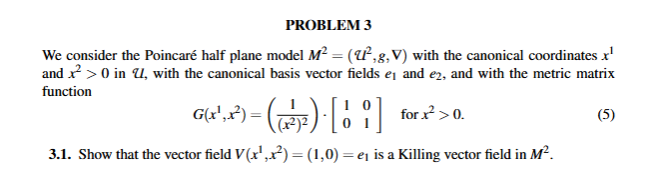

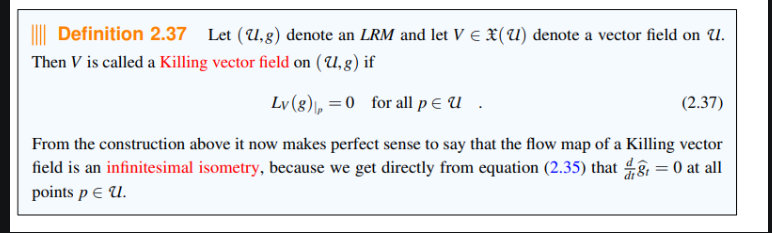

In [ ]:
x1, x2 = sp.symbols('x1 x2', real=True)

coords = sp.Matrix([x1,x2])

G = 1/(x2**2) * sp.eye(2)
display(G)

V = sp.Matrix([1, 0])


Lv_g = DG503.calculate_lie_derivative_metric(G, V, coords)

display(Lv_g)

Matrix([
[x2**(-2),        0],
[       0, x2**(-2)]])

Matrix([
[0, 0],
[0, 0]])

In [70]:
x1, x2 = sp.symbols('x1 x2', real=True)

coords = sp.Matrix([x1,x2])

G = 1/(x2**2) * sp.eye(2)
display(G)

W = sp.Matrix([0, 1])


Lv_g = DG503.calculate_lie_derivative_metric(G, W, coords)

display(Lv_g)

Matrix([
[x2**(-2),        0],
[       0, x2**(-2)]])

Matrix([
[-2/x2**3,        0],
[       0, -2/x2**3]])

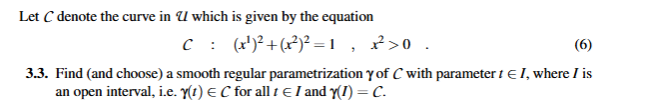

Circle with radius 1

In [78]:
t = sp.symbols('t', real=True)
gamma = sp.Matrix([sp.cos(t), sp.sin(t)])

display(gamma)

C = x1**2 + x2**2

display(C)

C_r = C.subs({x1: sp.cos(t), x2: sp.sin(t)})
display(sp.simplify(C_r))

Matrix([
[cos(t)],
[sin(t)]])

x1**2 + x2**2

1

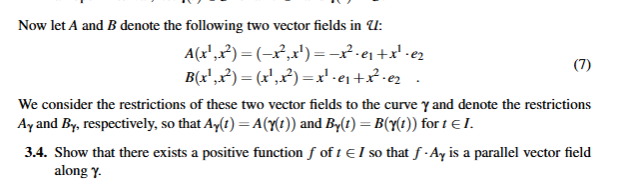

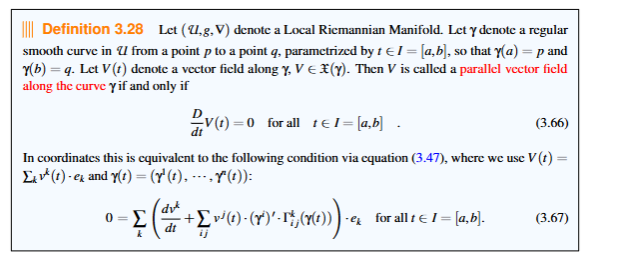

In [ ]:
A = sp.Matrix([-x2, x1])
B = sp.Matrix([x1, x2])

gamma = sp.Matrix([sp.cos(t), sp.sin(t)])

f = sp.Function('f')(t)

gamma_A = A.subs({x1: sp.cos(t), x2: sp.sin(t)})

cov_gamma = DG503.calculate_covariant_derivative_along_curve(G, gamma,f * gamma_A, t, coords)

display(sp.simplify(cov_gamma))
sol_1 = sp.dsolve(sp.Eq(cov_gamma[0], 0), f)
display(sol_1)
sol_2 = sp.dsolve(sp.Eq(cov_gamma[1], 0), f)
display(sol_2)

display(sp.simplify(cov_gamma.subs(f, sp.sin(t))))

Matrix([
[   f(t)*cos(t) - sin(t)*Derivative(f(t), t)],
[(-f(t)/tan(t) + Derivative(f(t), t))*cos(t)]])

Eq(f(t), C1*sin(t))

Eq(f(t), C1*sin(t))

Matrix([
[0],
[0]])

Remember not to change G before finding the christoffel symbols

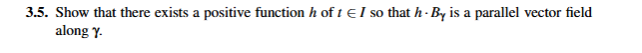

In [114]:
h = sp.Function('h')(t)

gamma_B = B.subs({x1: sp.cos(t), x2: sp.sin(t)})

cov_gamma = DG503.calculate_covariant_derivative_along_curve(G, gamma,h * gamma_B, t, coords)

display(sp.simplify(cov_gamma))
sol_1 = sp.dsolve(sp.Eq(cov_gamma[0], 0), h)
display(sol_1)
sol_2 = sp.dsolve(sp.Eq(cov_gamma[1], 0), h)
display(sol_2)

display(sp.simplify(cov_gamma.subs(h, sp.sin(t))))

Matrix([
[(-h(t)/tan(t) + Derivative(h(t), t))*cos(t)],
[  -h(t)*cos(t) + sin(t)*Derivative(h(t), t)]])

Eq(h(t), C1*sin(t))

Eq(h(t), C1*sin(t))

Matrix([
[0],
[0]])

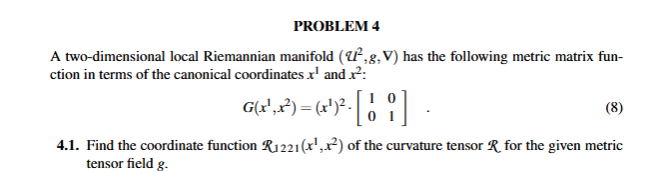

In [119]:
G = x1**2 * sp.eye(2)

coords = sp.Matrix([x1,x2])
display(G)

Curvature = DG503.curvature_tensor(G, coords)

display(Curvature[0,1,1,0])

Matrix([
[x1**2,     0],
[    0, x1**2]])

1

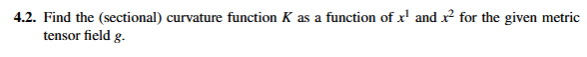

In [121]:
point= sp.Matrix([x1, x2])
V = sp.Matrix([1, 0])
W = sp.Matrix([0, 1])

Sec_curv = DG503.sectional_curvature(G,point,V,W, coords)
display(Sec_curv)

x1**(-4)